# One-Way ANOVA Simulation

{{< video ./figures/animations/PopulationSampling.mp4 >}}

{{< video ./figures/animations/GroupDifferenceSampling.mp4 >}}


In [ ]:
## Warning: to compile the notes you need the "bookdown" and the "broom" packages. Install them by
## running install.packages, see the commented lines below

if (!require("tidyverse")) {
  install.packages("tidyverse")
}

if (!require("broom")) {
  install.packages("broom")
}

suppressMessages(library(tidyverse))
suppressMessages(library(broom))

- <https://febse.github.io/econ2026/06-Simulation-Class.html>
- <https://www.desmos.com/calculator/nhzjgocxbz>

In [43]:
N <- 16
group <- rbinom(N, 1, 0.5)

pop_average <- 170 + 10 * group
pop_std_dev <- 10

response <- rnorm(N, mean=pop_average, sd=pop_std_dev) |> round(1)

pop <- tibble(group, pop_average, response) |>
    mutate(
        person_id = row_number(),
    )

pop |> head(n=16)

group,pop_average,response,person_id
<int>,<dbl>,<dbl>,<int>
0,170,163.4,1
0,170,161.5,2
1,180,186.4,3
0,170,163.1,4
0,170,152.0,5
0,170,167.1,6
0,170,161.1,7
0,170,176.2,8
0,170,153.4,9


In [23]:
pop |> summary()

     group           mu         response       person_id    
 Min.   :0.0   Min.   :160   Min.   :121.0   Min.   :    1  
 1st Qu.:0.0   1st Qu.:160   1st Qu.:157.0   1st Qu.: 2501  
 Median :0.5   Median :165   Median :165.0   Median : 5000  
 Mean   :0.5   Mean   :165   Mean   :164.8   Mean   : 5000  
 3rd Qu.:1.0   3rd Qu.:170   3rd Qu.:173.0   3rd Qu.: 7500  
 Max.   :1.0   Max.   :170   Max.   :203.0   Max.   :10000  

In [24]:
# Population averages and standard deviations

pop |>
    group_by(group) |>
    summarize(
        n = n(),
        pct = 100 * n / nrow(pop),
        mean = mean(response) |> round(1),
        sd = sd(response) |> round(1)
    )


group,n,pct,mean,sd
<int>,<int>,<dbl>,<dbl>,<dbl>
0,5000,50,170.0,10.0
1,5000,50,159.6,10.1


In [25]:
generate_samples <- function(pop_dt, sample_size, number_of_samples) {
    samples_list <- replicate(number_of_samples, pop_dt |> slice_sample(n = sample_size), simplify = FALSE)
    samples_dt <- samples_list |> 
        bind_rows(.id = "sample_id")
    return(samples_dt)
}

samples_2_3 <- generate_samples(pop_dt = pop, sample_size = 2, number_of_samples = 3)
samples_2_3

sample_id,group,mu,response,person_id
<chr>,<int>,<dbl>,<dbl>,<int>
1,0,170,171,9487
1,0,170,164,1056
2,1,160,141,2062
2,1,160,158,8074
3,0,170,171,3804
3,0,170,164,1108


In [26]:
lm_by_sample <- function(samples_dt) {
    
    # Run a linear regression of height on group in each sample and extract the coefficient using lm

    lm_result <- samples_dt |>
        group_by(sample_id) |>
        group_map(~ {
            model <- lm(response ~  group, data = .x)
            tidy(model) |>
                select(term, estimate, std.error) |>
                mutate(
                    sample_size = nrow(.x),
                    number_of_samples = length(unique(samples_dt$sample_id))
                )
        }) |>
        bind_rows(.id = "sample_id")
    
    return(lm_result)
}

In [27]:
sim1 <- lm_by_sample(samples_2_3)
sim1

sample_id,term,estimate,std.error,sample_size,number_of_samples
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
1,(Intercept),167.5,3.5,2,3
1,group,NA,NA,2,3
2,(Intercept),149.5,8.5,2,3
2,group,NA,NA,2,3
3,(Intercept),167.5,3.5,2,3
3,group,NA,NA,2,3


In [28]:
sim1 |> head()

sample_id,term,estimate,std.error,sample_size,number_of_samples
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
1,(Intercept),167.5,3.5,2,3
1,group,NA,NA,2,3
2,(Intercept),149.5,8.5,2,3
2,group,NA,NA,2,3
3,(Intercept),167.5,3.5,2,3
3,group,NA,NA,2,3


Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_bin()`).”


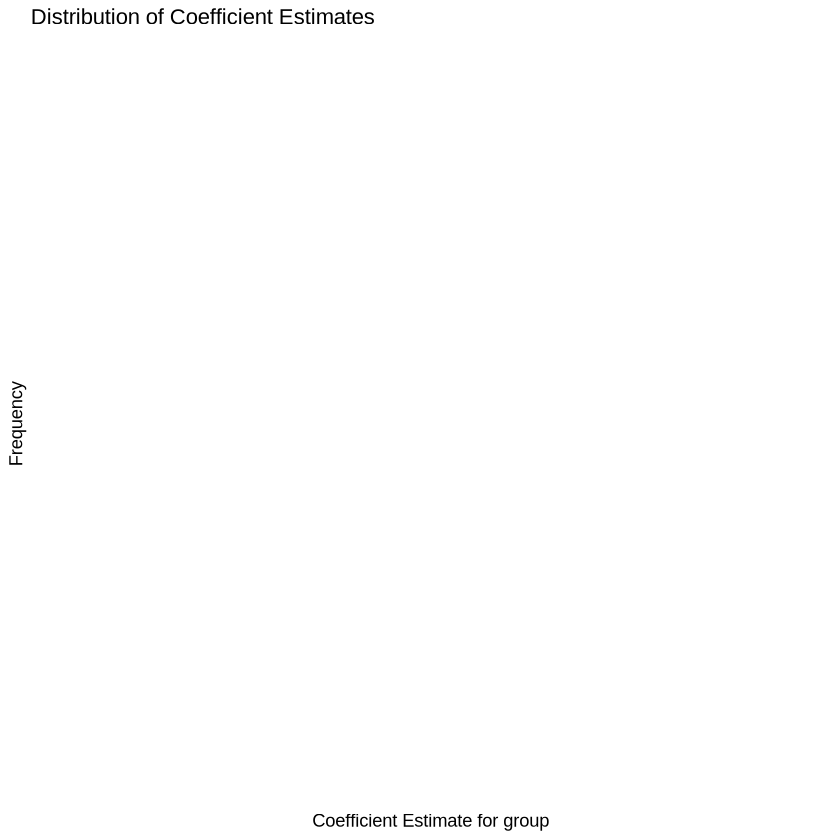

In [29]:
sim1 |> 
    filter(term == "group") |>
    ggplot(aes(x = estimate)) +
    geom_histogram(binwidth = 1, fill = "lightblue", color = "black") +
    labs(
        title = "Distribution of Coefficient Estimates",
        x = "Coefficient Estimate for group",
        y = "Frequency"
    ) +
    theme_minimal()

In [30]:
samples_50_1000 <- generate_samples(pop_dt = pop, sample_size = 50, number_of_samples = 1000)
samples_50_1000 |> head()

samples_100_1000 <- generate_samples(pop_dt = pop, sample_size = 200, number_of_samples = 1000)
samples_100_1000 |> head()

sample_id,group,mu,response,person_id
<chr>,<int>,<dbl>,<dbl>,<int>
1,1,160,153,521
1,1,160,168,4163
1,1,160,153,5756
1,0,170,162,7924
1,0,170,180,333
1,1,160,155,2706


sample_id,group,mu,response,person_id
<chr>,<int>,<dbl>,<dbl>,<int>
1,0,170,152,5732
1,1,160,151,1764
1,1,160,147,3138
1,1,160,167,8853
1,1,160,183,5508
1,1,160,155,1317


In [31]:
sim2 <- lm_by_sample(samples_50_1000)
sim3 <- lm_by_sample(samples_100_1000)

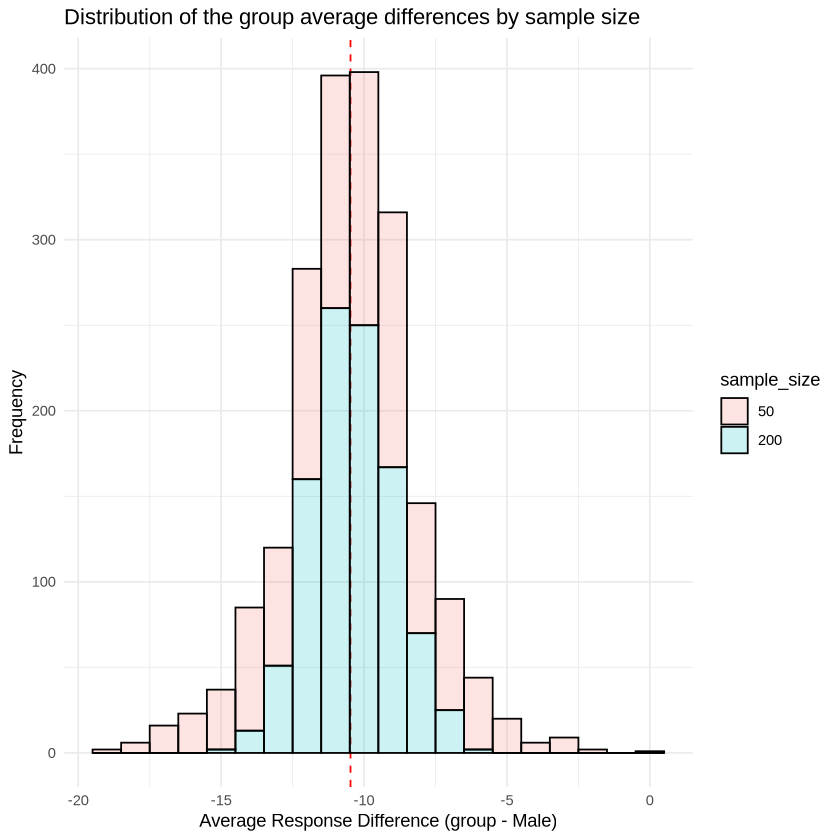

In [32]:
# Visualize the distribution of average response differences for both simulations

sim2 |>
    bind_rows(sim3) |>    
    filter(term == "group") |>
    mutate(sample_size = factor(sample_size)) |>
    ggplot(aes(x = estimate, fill=sample_size)) +
    geom_vline(xintercept = mean(pop$response[pop$group == 1]) - mean(pop$response[pop$group == 0]), linetype = "dashed", color = "red") +
    geom_histogram(binwidth = 1, color = "black", alpha=0.2) +
    labs(
        title = "Distribution of the group average differences by sample size",
        x = "Average Response Difference (group - Male)",
        y = "Frequency"
    ) +
    theme_minimal()


## Hypothesis Testing

Model:

$$
y_i = \beta_0 + \beta_1 \text{group}_i + e_i, \quad e_i \sim N(0, \sigma^2), \quad i = 1, \ldots, n
$$

$$
\begin{align*}
y_i \sim N(\mu_i, \sigma^2) \\
\mu_i = \beta_0 + \beta_1 \text{group}_i
\end{align*}
$$

$$
H_0: \beta_1 \geq \beta_1^{(H_0)} = 0 \\
H_1: \beta_1 < \beta_1^{(H_0)} = 0
$$

$$
H_0: \beta_1 \geq 0 \iff \mu_1 >  \mu_0\\
H_1: \beta_1 < 0 \iff \mu_1 \leq  \mu_0
$$

- <https://www.desmos.com/calculator/nhzjgocxbz>

$$
t = \frac{\hat{\beta}_1 - \beta_1^{(H_0)}}{SE(\hat{\beta}_1)}
$$

In [33]:
sim2 <- sim2 |>
    mutate(
        t_statistic = (estimate - 0) / std.error
    )

sim2 |> head()

sample_id,term,estimate,std.error,sample_size,number_of_samples,t_statistic
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,(Intercept),170.500000,2.162263,50,1000,78.852567
1,group,-9.266667,2.791470,50,1000,-3.319637
2,(Intercept),174.625000,1.897719,50,1000,92.018369
2,group,-14.355769,2.631663,50,1000,-5.455019
3,(Intercept),169.379310,1.583553,50,1000,106.961535
3,group,-9.617406,2.443476,50,1000,-3.935952


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


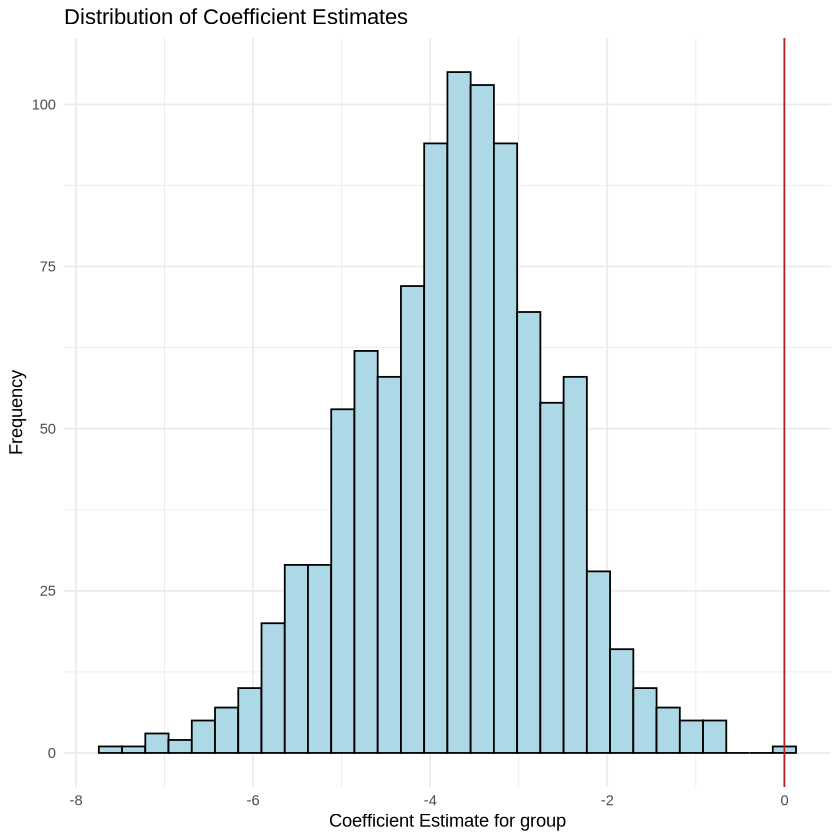

In [37]:
sim2 |>
    filter(term == "group") |>
    ggplot(aes(x = t_statistic)) +
    geom_histogram(fill = "lightblue", color = "black") +
    geom_vline(xintercept = 0, color="firebrick") + 
    labs(
        title = "Distribution of Coefficient Estimates",
        x = "Coefficient Estimate for group",
        y = "Frequency"
    ) +
    theme_minimal()